# Understanding the problem

# 📌 SGD Variants: Comparing Stochastic, Mini-Batch, and Full-Batch Gradient Descent

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Data collection

# ✅ Load the Housing Dataset

In [2]:
url = "https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/housing.csv"
df = pd.read_csv(url)

# Feature Engineering

# ✅ Prepare Features (X) and Target (y)

In [3]:
X = df.iloc[:, :-1].values  # Features (all columns except the last)
y = df.iloc[:, -1].values   # Target variable (last column)

# ✅ Split into Training & Test Sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Normalize Features (Gradient Descent is sensitive to scaling)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Add Bias Term (X0 = 1) for Intercept

In [6]:
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# 🔹 1️⃣ FULL-BATCH GRADIENT DESCENT 🔹

In [7]:
def full_batch_gd(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  # Initialize weights randomly
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)
        theta -= learning_rate * gradients
        cost = mean_squared_error(y, X @ theta)
        cost_history.append(cost)

    return theta, cost_history

# ✅ Run Full-Batch Gradient Descent

In [8]:
theta_full, cost_full = full_batch_gd(X_train_b, y_train)

# 🔹 2️⃣ MINI-BATCH GRADIENT DESCENT 🔹

In [9]:
def mini_batch_gd(X, y, learning_rate=0.01, epochs=1000, batch_size=32):
    m, n = X.shape
    theta = np.random.randn(n)  # Initialize weights randomly
    cost_history = []

    for epoch in range(epochs):
        shuffled_indices = np.random.permutation(m)  # Shuffle dataset
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, m, batch_size):  # Iterate over mini-batches
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            gradients = 2 / batch_size * X_batch.T @ (X_batch @ theta - y_batch)
            theta -= learning_rate * gradients

        cost = mean_squared_error(y, X @ theta)
        cost_history.append(cost)

    return theta, cost_history


# ✅ Run Mini-Batch Gradient Descent

In [10]:
theta_mini, cost_mini = mini_batch_gd(X_train_b, y_train)

# 🔹 3️⃣ STOCHASTIC GRADIENT DESCENT 🔹

In [11]:
def stochastic_gd(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  # Initialize weights randomly
    cost_history = []

    for epoch in range(epochs):
        for i in range(m):  # One update per sample
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]

            gradients = 2 * xi.T @ (xi @ theta - yi)
            theta -= learning_rate * gradients

        cost = mean_squared_error(y, X @ theta)
        cost_history.append(cost)

    return theta, cost_history


# ✅ Run Stochastic Gradient Descent

In [12]:
theta_sgd, cost_sgd = stochastic_gd(X_train_b, y_train)

# ✅ Compare Models on Test Data

In [13]:
y_pred_full = X_test_b @ theta_full
y_pred_mini = X_test_b @ theta_mini
y_pred_sgd = X_test_b @ theta_sgd

mse_full = mean_squared_error(y_test, y_pred_full)
mse_mini = mean_squared_error(y_test, y_pred_mini)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)

print(f"Full-Batch GD MSE: {mse_full:.4f}")
print(f"Mini-Batch GD MSE: {mse_mini:.4f}")
print(f"Stochastic GD MSE: {mse_sgd:.4f}")

Full-Batch GD MSE: 0.1506
Mini-Batch GD MSE: 0.1472
Stochastic GD MSE: 0.1639


# ✅ Visualization: Loss Reduction Comparison

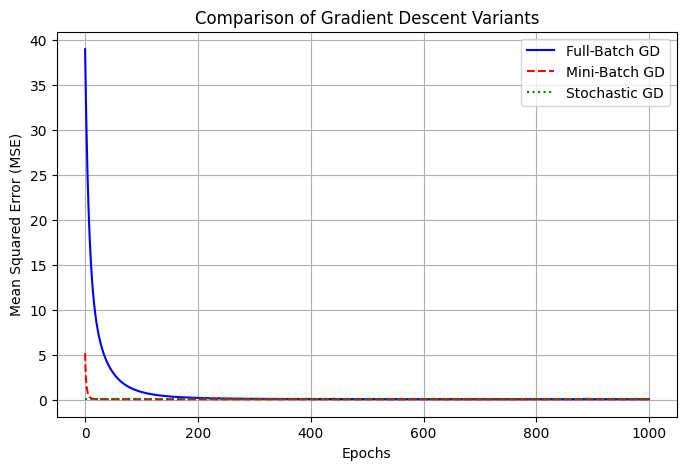

In [14]:
plt.figure(figsize=(8,5))
plt.plot(cost_full, label="Full-Batch GD", color="b")
plt.plot(cost_mini, label="Mini-Batch GD", color="r", linestyle="dashed")
plt.plot(cost_sgd, label="Stochastic GD", color="g", linestyle="dotted")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of Gradient Descent Variants")
plt.legend()
plt.grid()
plt.show()